# Multimodal Ensemble: CNN + OCR Text Classifier

This notebook loads the custom CNN (`custom_cnn_from_scratch_DA_fairness.pth`) and the OCR text classifier (`ocr_text_classifier.joblib`) and implements a threshold-based ensemble strategy. It includes: loading artifacts, computing per-sample probabilities, automatic threshold search to improve validation accuracy, evaluation, and an inference helper that combines both models.

In [19]:
# Install/ensure required packages (won't reinstall Tesseract)
import importlib, subprocess, sys
def ensure_package(pkg, import_name=None):
    m = import_name or pkg
    try:
        importlib.import_module(m)
        print(f'OK: {pkg} available')
    except ModuleNotFoundError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

ensure_package('torch')
ensure_package('torchvision')
ensure_package('pandas')
ensure_package('numpy')
ensure_package('scikit-learn', 'sklearn')
ensure_package('joblib')
ensure_package('Pillow', 'PIL')
ensure_package('matplotlib')
ensure_package('seaborn')

OK: torch available
OK: torchvision available
OK: pandas available
OK: numpy available
OK: scikit-learn available
OK: joblib available
OK: Pillow available
OK: matplotlib available
OK: seaborn available


In [20]:
# Imports
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Paths (workspace-relative)
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'Data'
MODELS_DIR = Path('Models')
CNN_WEIGHTS = MODELS_DIR / 'custom_cnn_from_scratch_DA_fairness.pth'
OCR_VECT = MODELS_DIR / 'ocr_vectorizer.joblib'
OCR_CLF = MODELS_DIR / 'ocr_text_classifier.joblib'
SAMPLES_CSV = MODELS_DIR / 'ocr_samples.csv'
CLASS_NAMES_JSON = MODELS_DIR / 'class_names.json'
print('CNN weights:', CNN_WEIGHTS)
print('OCR classifier:', OCR_CLF)
print('Samples CSV:', SAMPLES_CSV)

CNN weights: Models\custom_cnn_from_scratch_DA_fairness.pth
OCR classifier: Models\ocr_text_classifier.joblib
Samples CSV: Models\ocr_samples.csv


In [22]:
# Re-declare CustomCNN (must match architecture used during training)
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [23]:
# Load class names, CNN model weights, and OCR artifacts
with open(CLASS_NAMES_JSON, 'r') as f:
    class_names = json.load(f)
num_classes = len(class_names)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Initialize model and load weights
cnn = CustomCNN(num_classes=num_classes)
state = torch.load(CNN_WEIGHTS, map_location='cpu')
# state may be a state_dict or a raw model dict; assume state_dict
if isinstance(state, dict) and all(isinstance(v, torch.Tensor) for v in state.values()):
    cnn.load_state_dict(state)
else:
    # if the file stores only state under key 'model_state' or similar, try common keys
    if 'model_state' in state:
        cnn.load_state_dict(state['model_state'])
    elif 'state_dict' in state:
        cnn.load_state_dict(state['state_dict'])
    else:
        # last resort: try to load as state directly
        try:
            cnn.load_state_dict(state)
        except Exception as e:
            print('Failed to load CNN weights:', e)
cnn = cnn.to(device)
cnn.eval()

# Load OCR vectorizer and classifier
vectorizer = load(OCR_VECT)
ocr_clf = load(OCR_CLF)

# Load samples dataframe
samples_df = pd.read_csv(SAMPLES_CSV)
print('Loaded samples:', len(samples_df))
samples_df.head()

Loaded samples: 2764


,path,label,text
0,C:\Users\Lenovo\Desktop\UB\TFM\Data\Banner apl...,Banner aplicación,© 8 Fu\n\nInformacion sobre los\nDatos mostrad...
1,C:\Users\Lenovo\Desktop\UB\TFM\Data\Banner apl...,Banner aplicación,Informacion sobre los Datos mostrados\nen Caix...
2,C:\Users\Lenovo\Desktop\UB\TFM\Data\Banner apl...,Banner aplicación,100%@\n\nInformacion sobre los\nDatos mostrado...
3,C:\Users\Lenovo\Desktop\UB\TFM\Data\Banner apl...,Banner aplicación,23:21 Mt\n\nInformacion sobre los\nDatos mostr...
4,C:\Users\Lenovo\Desktop\UB\TFM\Data\Banner apl...,Banner aplicación,5:42 BOR = @ ull 100% &\n\nActualiza la app\n\...


In [24]:
# Image preprocessing (same pipeline as CNN training)
IMAGE_SIZE = (224, 224)
BORDER_CROP = 120
def safe_mobile_border_crop(img):
    crop_margin = min(BORDER_CROP, max((img.height - 1) // 2, 0))
    return img.crop((0, crop_margin, img.width, img.height - crop_margin))

cnn_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def preprocess_image_for_cnn(path, transform=cnn_transform, device=device):
    img = Image.open(path).convert('RGB')
    t = transform(img).unsqueeze(0).to(device)
    return t

In [25]:
# Create evaluation split from samples CSV (stratified)
X = samples_df['path']
y = samples_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
val_df = pd.DataFrame({'path': X_val.values, 'label': y_val.values})
print('Validation samples:', len(val_df))

Validation samples: 553


In [26]:
# Compute CNN probabilities for validation set (batching to avoid memory issues)
cnn_probs = []
cnn_preds = []
batch = []
paths = []
BATCH_SIZE = 32
for i, row in val_df.iterrows():
    p = row['path']
    try:
        t = preprocess_image_for_cnn(p)
    except Exception as e:
        # on error, substitute zeros
        cnn_probs.append(np.zeros(num_classes))
        cnn_preds.append(None)
        continue
    batch.append((p, t))
    if len(batch) >= BATCH_SIZE:
        imgs = torch.cat([b[1] for b in batch], dim=0)
        with torch.no_grad():
            logits = cnn(imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        for (pp, _), pr in zip(batch, probs):
            cnn_probs.append(pr)
            cnn_preds.append(int(pr.argmax()))
        batch = []
# leftover
if batch:
    imgs = torch.cat([b[1] for b in batch], dim=0)
    with torch.no_grad():
        logits = cnn(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    for (pp, _), pr in zip(batch, probs):
        cnn_probs.append(pr)
        cnn_preds.append(int(pr.argmax()))

cnn_probs = np.array(cnn_probs)
cnn_confidences = cnn_probs.max(axis=1)
cnn_pred_labels = [class_names[idx] if idx is not None else 'error' for idx in cnn_preds]
len(cnn_probs)

553

In [27]:
# Compute OCR probabilities for validation set
texts = []
for p in val_df['path'].values:
    # retrieve the text from samples_df (it contains OCR text we extracted earlier)
    txt_row = samples_df.loc[samples_df['path'] == p, 'text']
    if not txt_row.empty and pd.notna(txt_row.values[0]):
        texts.append(str(txt_row.values[0]))
    else:
        texts.append('')
X_val_t = vectorizer.transform(texts)
ocr_probs = ocr_clf.predict_proba(X_val_t)
ocr_confidences = ocr_probs.max(axis=1)
ocr_pred_indices = ocr_probs.argmax(axis=1)
ocr_pred_labels = [ocr_clf.classes_[i] for i in ocr_pred_indices]
len(ocr_probs)


553

In [28]:
# Ensure arrays align and create a combined DataFrame for evaluation
n = len(val_df)
assert len(cnn_probs) == n and len(ocr_probs) == n, 'Mismatch in computed probabilities length'
eval_df = val_df.copy().reset_index(drop=True)
eval_df['true'] = eval_df['label']
eval_df['cnn_conf'] = cnn_confidences
eval_df['cnn_pred'] = cnn_pred_labels
eval_df['ocr_conf'] = ocr_confidences
eval_df['ocr_pred'] = ocr_pred_labels
eval_df.head()

,path,label,true,cnn_conf,cnn_pred,ocr_conf,ocr_pred
0,C:\Users\Lenovo\Desktop\UB\TFM\Data\Revisión c...,Revisión circuito,Revisión circuito,0.807325,Revisión circuito,0.856403,Revisión circuito
1,C:\Users\Lenovo\Desktop\UB\TFM\Data\Cierre apl...,Cierre aplicación,Cierre aplicación,0.975868,Cierre aplicación,0.956634,Cierre aplicación
2,C:\Users\Lenovo\Desktop\UB\TFM\Data\Timeout\Pu...,Timeout,Timeout,0.872612,Timeout,0.708760,Timeout
3,C:\Users\Lenovo\Desktop\UB\TFM\Data\Error func...,Error funcional,Error funcional,0.910229,Error funcional,0.416787,Error funcional
4,C:\Users\Lenovo\Desktop\UB\TFM\Data\Revisión c...,Revisión circuito,Revisión circuito,0.850699,Revisión circuito,0.762373,Revisión circuito


Strategy accuracy: 0.9927667269439421

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        20
Cierre aplicación       1.00      1.00      1.00        31
 Error aplicativo       1.00      0.97      0.99        36
  Error funcional       0.96      1.00      0.98       107
   Error terminal       1.00      1.00      1.00        81
    Indeterminado       1.00      1.00      1.00         3
Revisión circuito       1.00      0.99      1.00       236
          Timeout       1.00      0.97      0.99        39

         accuracy                           0.99       553
        macro avg       1.00      0.99      0.99       553
     weighted avg       0.99      0.99      0.99       553



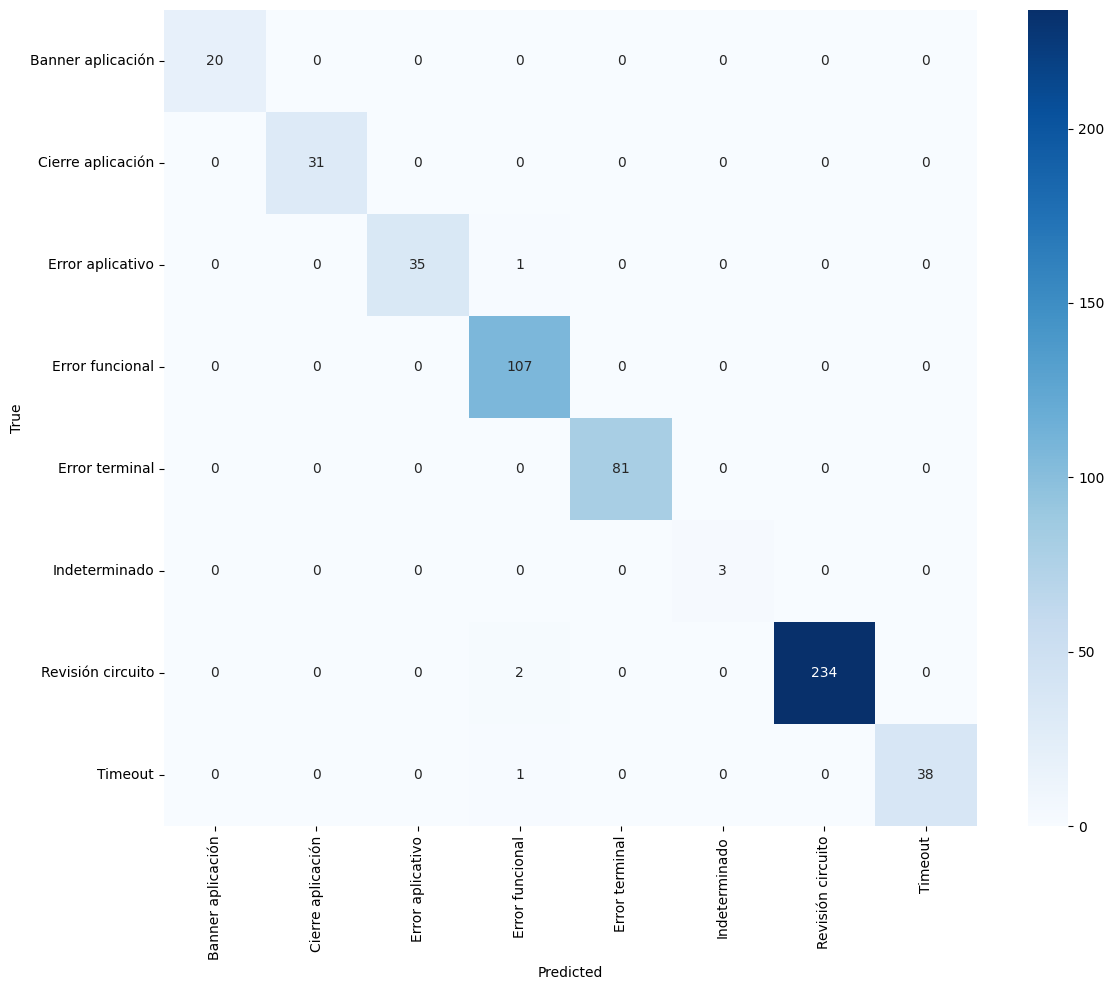


Reason counts:
strategy_reason
combined_threshold    369
combined_fallback     130
cnn_high_ocr_ok        54
Name: count, dtype: int64


In [29]:
# Evaluate the user-specified ensemble strategy on the validation set
strategy_preds = []
strategy_reasons = []
strategy_confs = []
for i in range(len(eval_df)):
    cnn_p = cnn_probs[i]
    ocr_p = ocr_probs[i]
    pred_label, conf, reason = ensemble_predict_row(cnn_p, ocr_p, class_names, ocr_clf.classes_, combined_thresh=1.65, cnn_thresh=0.85, ocr_thresh=0.50)
    strategy_preds.append(pred_label)
    strategy_reasons.append(reason)
    strategy_confs.append(conf)

print('Strategy accuracy:', accuracy_score(eval_df['true'], strategy_preds))
print('\nClassification report:')
print(classification_report(eval_df['true'], strategy_preds))

cm = confusion_matrix(eval_df['true'], strategy_preds, labels=class_names)
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, ax=ax, cmap='Blues')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

# Add strategy results to eval_df for inspection
eval_df['strategy_pred'] = strategy_preds
eval_df['strategy_reason'] = strategy_reasons
eval_df['strategy_conf'] = strategy_confs

# Show summary of reasons
print('\nReason counts:')
print(eval_df['strategy_reason'].value_counts())


In [30]:
# Threshold-based decision rule function (user-specified strategy)
def ensemble_predict_row(cnn_prob, ocr_prob, cnn_classes, ocr_classes, combined_thresh=1.65, cnn_thresh=0.85, ocr_thresh=0.50):
    # Align OCR probabilities to the CNN class ordering
    ocr_aligned = np.zeros_like(cnn_prob)
    for i, lbl in enumerate(ocr_classes):
        try:
            j = cnn_classes.index(lbl)
            ocr_aligned[j] = ocr_prob[i]
        except ValueError:
            # OCR predicted a label not present in CNN classes; ignore
            continue

    # Combined per-class score = cnn_prob + ocr_aligned
    combined = cnn_prob + ocr_aligned
    idx = int(np.argmax(combined))
    combined_max = float(combined[idx])
    combined_label = cnn_classes[idx]

    # Step 1: If combined probability for top class >= combined_thresh, predict that class
    if combined_max >= combined_thresh:
        return combined_label, combined_max, 'combined_threshold'

    # Step 2: If CNN >= cnn_thresh and OCR >= ocr_thresh, predict CNN class
    cnn_conf = float(cnn_prob.max())
    ocr_conf = float(ocr_prob.max())
    cnn_label = cnn_classes[int(np.argmax(cnn_prob))]
    if cnn_conf >= cnn_thresh and ocr_conf >= ocr_thresh:
        return cnn_label, cnn_conf, 'cnn_high_ocr_ok'

    # Step 3: fallback - choose class with highest combined score
    return combined_label, combined_max, 'combined_fallback'


In [31]:
# Grid-search thresholds to maximize validation accuracy
best = {'acc': -1}
ocr_thresh_values = np.linspace(0.4, 0.95, 12)
cnn_thresh_values = np.linspace(0.3, 0.9, 13)
for o_t in ocr_thresh_values:
    for c_t in cnn_thresh_values:
        preds = []
        for i in range(len(eval_df)):
            row = eval_df.iloc[i]
            cnn_p = cnn_probs[i]
            ocr_p = ocr_probs[i]
            pred_label, conf, reason = ensemble_predict_row(cnn_p, ocr_p, class_names, ocr_clf.classes_, ocr_thresh=o_t, cnn_thresh=c_t)
            preds.append(pred_label)
        acc = accuracy_score(eval_df['true'], preds)
        if acc > best['acc']:
            best = {'acc': acc, 'ocr_thresh': float(o_t), 'cnn_thresh': float(c_t), 'preds': preds}
best

{'acc': 0.9945750452079566,
 'ocr_thresh': 0.4,
 'cnn_thresh': 0.3,
 'preds': ['Revisión circuito',
  'Cierre aplicación',
  'Timeout',
  'Error funcional',
  'Revisión circuito',
  'Revisión circuito',
  'Cierre aplicación',
  'Error terminal',
  'Error funcional',
  'Timeout',
  'Error aplicativo',
  'Error funcional',
  'Revisión circuito',
  'Revisión circuito',
  'Error funcional',
  'Error aplicativo',
  'Error terminal',
  'Revisión circuito',
  'Timeout',
  'Timeout',
  'Cierre aplicación',
  'Revisión circuito',
  'Revisión circuito',
  'Error terminal',
  'Revisión circuito',
  'Revisión circuito',
  'Error funcional',
  'Banner aplicación',
  'Error funcional',
  'Error aplicativo',
  'Error terminal',
  'Revisión circuito',
  'Revisión circuito',
  'Cierre aplicación',
  'Revisión circuito',
  'Cierre aplicación',
  'Error terminal',
  'Error terminal',
  'Revisión circuito',
  'Error funcional',
  'Timeout',
  'Error funcional',
  'Error terminal',
  'Revisión circuito',
 

Best accuracy on validation: 0.9945750452079566
Best OCR threshold: 0.4
Best CNN threshold: 0.3

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        20
Cierre aplicación       1.00      1.00      1.00        31
 Error aplicativo       1.00      0.97      0.99        36
  Error funcional       0.97      1.00      0.99       107
   Error terminal       1.00      1.00      1.00        81
    Indeterminado       1.00      1.00      1.00         3
Revisión circuito       1.00      1.00      1.00       236
          Timeout       1.00      0.97      0.99        39

         accuracy                           0.99       553
        macro avg       1.00      0.99      0.99       553
     weighted avg       0.99      0.99      0.99       553



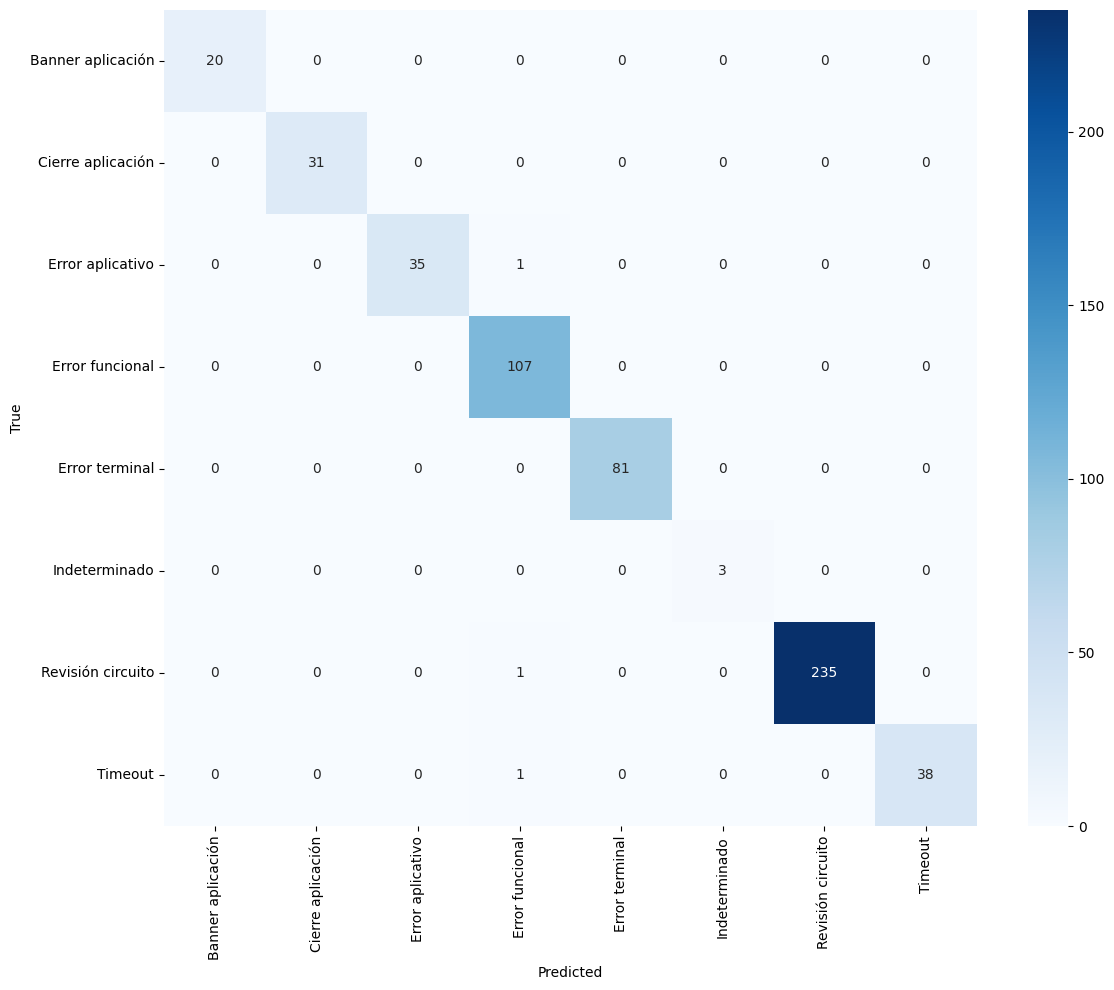

In [32]:
# Report best thresholds and evaluation metrics
print('Best accuracy on validation:', best['acc'])
print('Best OCR threshold:', best['ocr_thresh'])
print('Best CNN threshold:', best['cnn_thresh'])
preds = best['preds']
print('\nClassification report:')
print(classification_report(eval_df['true'], preds))
cm = confusion_matrix(eval_df['true'], preds, labels=class_names)
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, ax=ax, cmap='Blues')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()


In [33]:
# Inference helper combining both models with chosen thresholds
OCR_THRESH = best['ocr_thresh']
CNN_THRESH = best['cnn_thresh']
def predict_multimodal(image_path, return_details=False):
    # OCR path: use previously extracted text if present in samples_df, else run pytesseract live
    txt_row = samples_df.loc[samples_df['path'] == str(image_path), 'text']
    if not txt_row.empty:
        txt = txt_row.values[0]
    else:
        from PIL import Image
        import pytesseract
        img = Image.open(image_path).convert('RGB')
        txt = pytesseract.image_to_string(img).strip()
    # OCR probabilities
    vt = vectorizer.transform([txt])
    ocr_p = ocr_clf.predict_proba(vt)[0]
    ocr_conf = float(ocr_p.max())
    ocr_label = ocr_clf.classes_[int(ocr_p.argmax())]
    # CNN probabilities
    t = preprocess_image_for_cnn(image_path)
    with torch.no_grad():
        logits = cnn(t)
        cnn_p = torch.softmax(logits, dim=1).cpu().numpy()[0]
    cnn_conf = float(cnn_p.max())
    cnn_label = class_names[int(cnn_p.argmax())]
    pred_label, conf, reason = ensemble_predict_row(cnn_p, ocr_p, class_names, ocr_clf.classes_, ocr_thresh=OCR_THRESH, cnn_thresh=CNN_THRESH)
    if return_details:
        return {'predicted': pred_label, 'confidence': conf, 'reason': reason, 'ocr_label': ocr_label, 'ocr_conf': ocr_conf, 'cnn_label': cnn_label, 'cnn_conf': cnn_conf, 'text': txt}
    return pred_label

# Example inference on one sample from validation
example = val_df.iloc[0]['path']
print('Example path:', example)
print(predict_multimodal(example, return_details=True))

Example path: C:\Users\Lenovo\Desktop\UB\TFM\Data\Revisión circuito\Transacciones\20260504223854_100165.png
{'predicted': 'Revisión circuito', 'confidence': 1.6637285947799683, 'reason': 'combined_threshold', 'ocr_label': 'Revisión circuito', 'ocr_conf': 0.8564032082635514, 'cnn_label': 'Revisión circuito', 'cnn_conf': 0.8073253631591797, 'text': '22:42 m@O@ ° KX Aull 3%\n\n< ®\nCuenta *0047\n\nViernes 19\n€< QuotaT. Visa E- -0,24€\n>\np »\n0,00€\nMiércoles 17\n<  Ven.ac. +0,23€\n=> :\nCaixabank »\n0,24€\n< _ Traspaso Propio +0,01€\n“2 0,01€ ?\n<  Traspaso -0,01€\n— 0,00€ >\n<  Traspaso +0,01€\n2 0,01€ ?\nNoviembre 2025\nMiércoles 26\n< Cuota DiaA Dia -0,10€\n- 0,00€ ?\n\nIII O <'}


**Notes & Next steps**
- The threshold search above picks thresholds that maximize validation accuracy; you may prefer optimizing for other metrics (balanced accuracy, F1, or minimizing uncertain rate).
- Optionally implement a weighted-probability ensemble (alpha * cnn_prob + (1-alpha) * ocr_prob) and tune alpha.
- For production, serialize the chosen thresholds and the `predict_multimodal` helper as a small Python module.